<a href="https://colab.research.google.com/github/tadesseabera95-ship-it/Phishing-Detection-ML/blob/main/Emailphishing_detection_Using_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [5]:
####Download the dataset from kaggle
!pip install kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d subhajournal/phishingemails

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/subhajournal/phishingemails
License(s): GNU Lesser General Public License 3.0
100% 18.0M/18.0M [00:01<00:00, 16.2MB/s]



In [6]:
!unzip /content/phishingemails.zip

Archive:  /content/phishingemails.zip
  inflating: Phishing_Email.csv      


In [58]:
### Import Necessary libs
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Embedding,GRU,LSTM,Bidirectional,SimpleRNN
from tensorflow.keras.utils import pad_sequences
from sklearn.preprocessing import LabelEncoder
from keras.models import Sequential
import re
from keras.layers import Dense,Dropout
import tensorflow as tf
import warnings

warnings.filterwarnings('ignore')

In [9]:
#Loading our datasets extracted from kaggle copy the path of the file
df = pd.read_csv("/content/Phishing_Email.csv")

In [12]:
df.head() #pring the first some head(begining row) elements of the dataset

,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [13]:
df.tail() #pring the last some tail(begining row) elements of the dataset

,Unnamed: 0,Email Text,Email Type
18645,18646,date a lonely housewife always wanted to date ...,Phishing Email
18646,18647,request submitted : access request for anita ....,Safe Email
18647,18648,"re : important - prc mtg hi dorn & john , as y...",Safe Email
18648,18649,press clippings - letter on californian utilit...,Safe Email
18649,18650,empty,Phishing Email


In [14]:
df.describe()

,Unnamed: 0
count,18650.000000
mean,9325.154477
std,5384.327293
min,0.000000
25%,4662.250000
50%,9325.500000
75%,13987.750000
max,18650.000000


In [15]:
# checking the dataset dimensions (number of rows, number of columns)
df.shape

(18650, 3)

In [16]:
#The dataset preprocessing
# checking for missing values in each column
df.isnull().sum()


,0
Unnamed: 0,0
Email Text,16
Email Type,0


The result shows There are 16 rows available that have null values .  so Let's remove these rows to reduce the overhead because they are not importat and well labeled

Raw text data is messy. We must clean it before feeding it to any model.
* Check for missing/null values  
* Remove duplicates and null rows
*  Visualise class distribution

In [18]:
# Drop duplicates and null values
df.drop(["Unnamed: 0"],axis=1,inplace=True)#modify on the dataset not generate new
df.dropna(inplace=True,axis=0)
df.drop_duplicates(inplace=True)#modify on the dataset not generate new

In [20]:
# checking the dataset dimensions after processing
df.shape

(17538, 2)

In [26]:
#check the classification of the email types as phishing and safe email by Creating the bar chart
chart = px.bar(df['Email Type'].value_counts(),
               x=df['Email Type'].value_counts().index,
               y=df['Email Type'].value_counts().values,
             color=['blue', 'red'],
               labels={'x': 'Category', 'y': 'Count'},
             title="Categorical Distribution")
chart.show()

The bar chart shows that The count of the safe emails is more than that of phishing email.

In [134]:
#Encode labels to integers for easier handling
le = LabelEncoder()

df["Email Type"] = le.fit_transform(df["Email Type"])

In [135]:
df

,Email Text,Email Type
0,re 6 1100 disc uniformitarianism re 1086 sex l...,0
1,the other side of galicismos galicismo is a sp...,0
2,re equistar deal tickets are you still availab...,0
3,hello i am your hot lil horny toy i am the one...,1
4,software at incredibly low prices 86 lower dra...,1
...,...,...
18644,rick moen a ãcrit im confused i thought it was...,0
18645,date a lonely housewife always wanted to date ...,1
18646,request submitted access request for anita dup...,0
18647,re important prc mtg hi dorn john as you disco...,0


In [49]:
df.shape

(17538, 2)

# PRE-PTEXTROCESSING
1.   Lowercasing
2.   Punctuation Removal
3.   Tokenization
4.   StopWord Removal
5.   Lemmatization

 Cleans a single email string:
    
    
    1.Remove hyperlinks (URLs) — they don't carry useful word-level information and vary wildly between emails.
    2.Remove punctuation — keeps only alphanumeric characters and whitespace.
    3.Convert to lowercase — "Hello" and "hello" should be the same token.
    4.Remove extra whitespace — collapses multiple spaces into one, trims edges.

In [136]:
#Text Cleaning Function
import re

def preprocess_text(text):
    # Remove hyperlinks
    text = re.sub(r'http\S+', '', text)

    # Remove punctuations
    text = re.sub(r'[^\w\s]', '', text)

    # Convert to lowercase
    text = text.lower()

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# Apply the preprocess_text function to the specified column in the DataFrame
df["Email Text"] =df["Email Text"].apply(preprocess_text)


**WordCloud Visualisations **


Word clouds show the most frequent words — bigger = more frequent.

 With stopwords filtered out(common words like "the", "is", "a" removed)

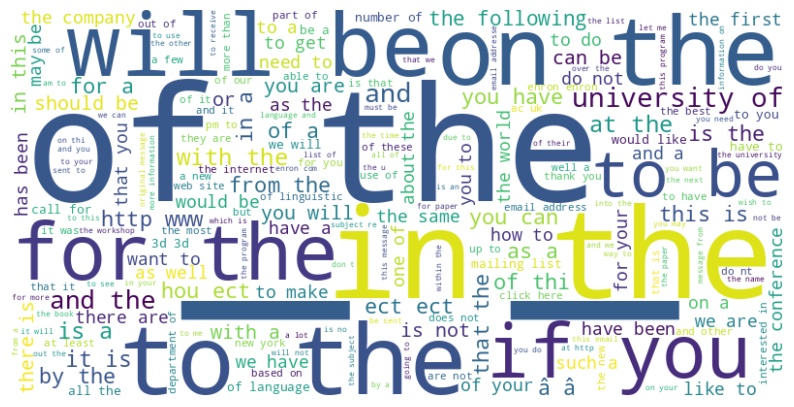

In [138]:
from wordcloud import WordCloud

## Concatenate all emails into one big string
all_mails = " ".join(df['Email Text'])

#create a wordcloud object
word_cloud = WordCloud(stopwords="english",width=800,height=400,background_color='white').generate(all_mails)

plt.figure(figsize=(10,6))
plt.imshow(word_cloud,interpolation='bilinear')
plt.axis("off")
plt.show()

In [139]:
df

,Email Text,Email Type
0,re 6 1100 disc uniformitarianism re 1086 sex l...,0
1,the other side of galicismos galicismo is a sp...,0
2,re equistar deal tickets are you still availab...,0
3,hello i am your hot lil horny toy i am the one...,1
4,software at incredibly low prices 86 lower dra...,1
...,...,...
18644,rick moen a ãcrit im confused i thought it was...,0
18645,date a lonely housewife always wanted to date ...,1
18646,request submitted access request for anita dup...,0
18647,re important prc mtg hi dorn john as you disco...,0


**Converting text into vector**
  
  
  TF-IDF Vectorisation

 TF-IDF (Term Frequency – Inverse Document Frequency):

    TF(t, d)  = (number of times term t appears in document d)
                / (total number of terms in d)

    IDF(t)    = log( N / (1 + df(t)) )
                where N = total documents, df(t) = documents containing term t

    TF-IDF(t, d) = TF(t, d) × IDF(t)


In [140]:
tf = TfidfVectorizer(stop_words="english", # Remove English stopwords before computing TF-IDF
max_features=10000) #dimensionality reduction to avoid memory issues
                     # Keep only the top 10,000 most informative words

feature_x = tf.fit_transform(df["Email Text"]).toarray() # fit_transform: Learns the vocabulary (fit) and converts emails to vectors (transform).
# .toarray(): Converts sparse matrix → dense numpy array (required by some models).
# Result shape: (n_emails, 10000) — each email is a vector of 10,000 TF-IDF scores.
y_tf = np.array(df['Email Type']) # convert the label into numpy array

** Splitting the dataset into train and test**

In [141]:
x_train_ml, x_test_ml, y_train_ml, y_test_ml = train_test_split(
    feature_x,      # Features (TF-IDF vectors)
    y_tf,           # Labels (0 = safe, 1 = phishing)
    train_size=0.8, # 80% of data for training, 20% for testing
    random_state=0  # Fixed seed → reproducible results every run
)
# Training set: model learns patterns from this.
# Test set:     model never sees this during training → fair evaluation.

Applying different ML Models and compare the performance of each model for emailphishing classification

1.Naive Bayes

In [142]:
#Naive bayes works with condtional probability
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(x_train_ml,y_train_ml)

MultinomialNB()

accuracy from native bayes: 97.55 %
f1 score from naive bayes: 96.80 %
classification report :

               precision    recall  f1-score   support

           0       0.98      0.98      0.98      2157
           1       0.97      0.96      0.97      1351

    accuracy                           0.98      3508
   macro avg       0.97      0.97      0.97      3508
weighted avg       0.98      0.98      0.98      3508



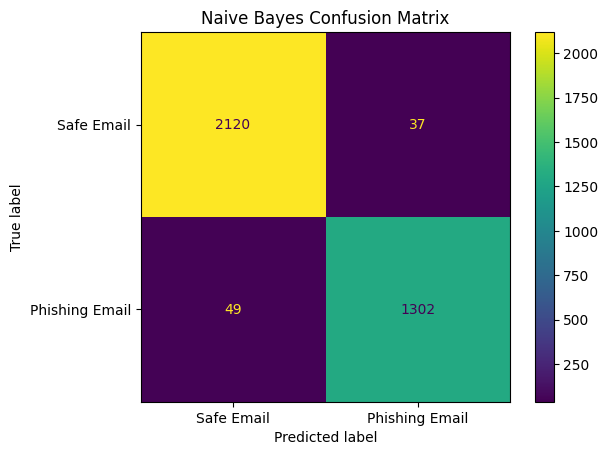

In [144]:
from sklearn.metrics import accuracy_score,f1_score,classification_report,ConfusionMatrixDisplay,confusion_matrix
pred_nav = nb.predict(x_test_ml)

# Checking the performance

print(f"accuracy from native bayes: {accuracy_score(y_test_ml,pred_nav)*100:.2f} %")
print(f"f1 score from naive bayes: {f1_score(y_test_ml,pred_nav)*100:.2f} %")
print("classification report :\n\n",classification_report(y_test_ml,pred_nav))

#confusion matrix
clf_nav = confusion_matrix(y_test_ml,pred_nav)
cx_ = ConfusionMatrixDisplay(clf_nav,display_labels=['Safe Email','Phishing Email']).plot()
plt.title("Naive Bayes Confusion Matrix")
plt.show()

2.Logistic Regression

Logistic Regression:
    Fits a linear boundary between classes.
    
    Output = sigmoid(w·x + b), giving a probability between 0 and 1.
    Threshold at 0.5: above = phishing, below = safe.
    Efficient, interpretable, strong baseline for text classification.


accuracy from logistic regression:97.95 %
f1 score from logistic regression: 97.31 %
classification report : 
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      2157
           1       0.98      0.96      0.97      1351

    accuracy                           0.98      3508
   macro avg       0.98      0.98      0.98      3508
weighted avg       0.98      0.98      0.98      3508



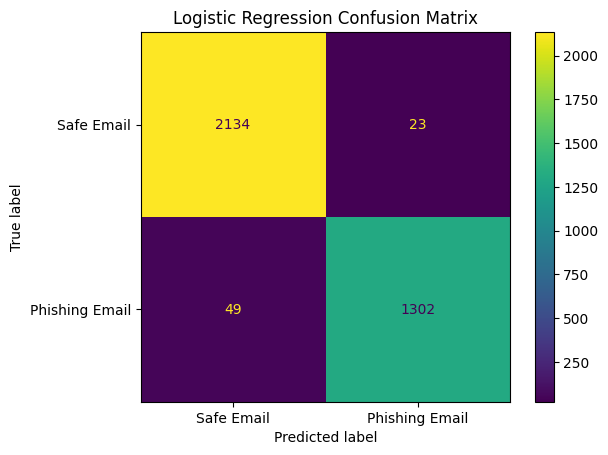

In [115]:
lg = LogisticRegression()
lg.fit(x_train_ml,y_train_ml)

# prediction
pred_lg = lg.predict(x_test_ml)
# performance
print("")
print(f"accuracy from logistic regression:{accuracy_score(y_test_ml,pred_lg)*100:.2f} %")
print(f"f1 score from logistic regression: {f1_score(y_test_ml,pred_lg)*100:.2f} %")
print("classification report : \n",classification_report(y_test_ml,pred_lg))

clf_lg = confusion_matrix(y_test_ml,pred_lg)
cx_ = ConfusionMatrixDisplay(clf_lg,display_labels=['Safe Email','Phishing Email']).plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [117]:
# save the model for future use

import joblib

# Save the trained model to a file
joblib.dump(nb, 'email_spam_nb.pkl')

['email_spam_nb.pkl']

**3.SGD Classifier**

SGDClassifier (Stochastic Gradient Descent):
    Updates model weights using ONE sample at a time (stochastic).
    Very fast on large datasets. With default settings, it approximates
    a linear SVM (Support Vector Machine).
    Useful when training data is too large to fit in memory.

accuracy from SGD Classifier:98.26 %
f1 score from SGD Classifier: 97.73 %
classification report : 
               precision    recall  f1-score   support

           0       0.98      0.99      0.99      2157
           1       0.98      0.97      0.98      1351

    accuracy                           0.98      3508
   macro avg       0.98      0.98      0.98      3508
weighted avg       0.98      0.98      0.98      3508



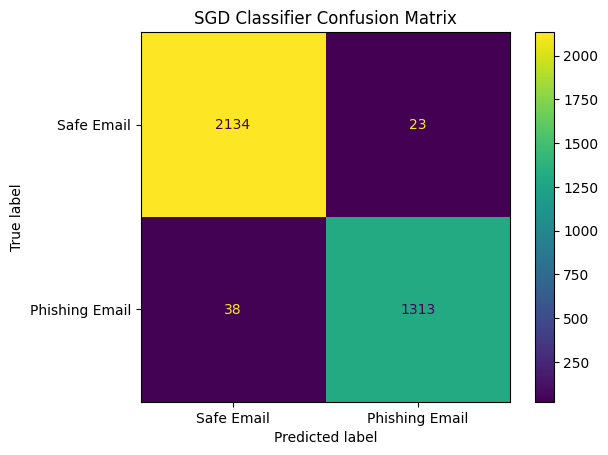

In [118]:
from sklearn.linear_model import SGDClassifier

# passing object
sgd = SGDClassifier()
sgd.fit(x_train_ml,y_train_ml)

# prediction
pred_sgd = sgd.predict(x_test_ml)
# performance
print(f"accuracy from SGD Classifier:{accuracy_score(y_test_ml,pred_sgd)*100:.2f} %")
print(f"f1 score from SGD Classifier: {f1_score(y_test_ml,pred_sgd)*100:.2f} %")
print("classification report : \n",classification_report(y_test_ml,pred_sgd))

clf_sgd = confusion_matrix(y_test_ml,pred_sgd)
cx_ = ConfusionMatrixDisplay(clf_sgd,display_labels=['Safe Email','Phishing Email']).plot()
plt.title("SGD Classifier Confusion Matrix")
plt.show()

**4.XGBoost**

XGBoost (Extreme Gradient Boosting):
    An ensemble method that builds trees SEQUENTIALLY.
    Each new tree corrects the residual errors of all previous trees.
    Uses regularisation (L1/L2) to control overfitting.
    One of the most powerful algorithms for structured/tabular data.
    Here applied to TF-IDF vectors (which are essentially tabular).

accuracy from XGB:97.26 %
f1 score from XGB: 96.45 %
classification report : 
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      2157
           1       0.96      0.97      0.96      1351

    accuracy                           0.97      3508
   macro avg       0.97      0.97      0.97      3508
weighted avg       0.97      0.97      0.97      3508



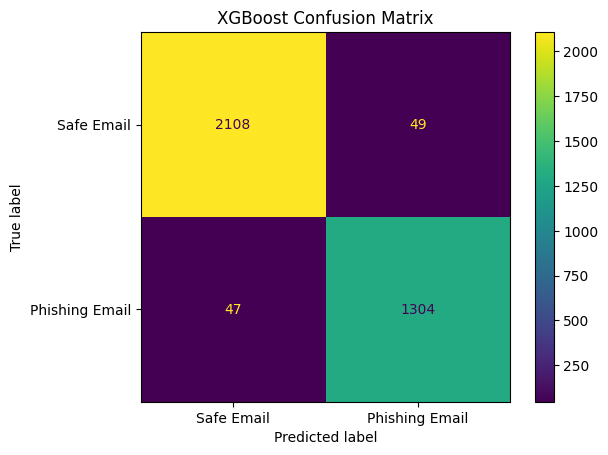

In [119]:
# applying boosting algorithm
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(x_train_ml,y_train_ml)

#prediction
pred_xgb = xgb.predict(x_test_ml)

#performance
print(f"accuracy from XGB:{accuracy_score(y_test_ml,pred_xgb)*100:.2f} %")
print(f"f1 score from XGB: {f1_score(y_test_ml,pred_xgb)*100:.2f} %")
print("classification report : \n",classification_report(y_test_ml,pred_xgb))

#confusion matrix
clf_xgb = confusion_matrix(y_test_ml,pred_xgb)
cx_ = ConfusionMatrixDisplay(clf_xgb,display_labels=['Safe Email','Phishing Email']).plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

**5.Decision Tree**

Decision Tree:
    Builds a tree of if-else rules based on feature values.
    Each internal node is a condition (e.g., "Does 'verify' appear > 0.1?")
    Each leaf node assigns a class.
    Very interpretable, but prone to overfitting on training data.
    Typically lower accuracy than ensemble methods.

accuracy from Decision Tree:93.16 %
f1 score from Decision Tree: 91.27 %
classification report : 
               precision    recall  f1-score   support

           0       0.95      0.93      0.94      2157
           1       0.90      0.93      0.91      1351

    accuracy                           0.93      3508
   macro avg       0.93      0.93      0.93      3508
weighted avg       0.93      0.93      0.93      3508



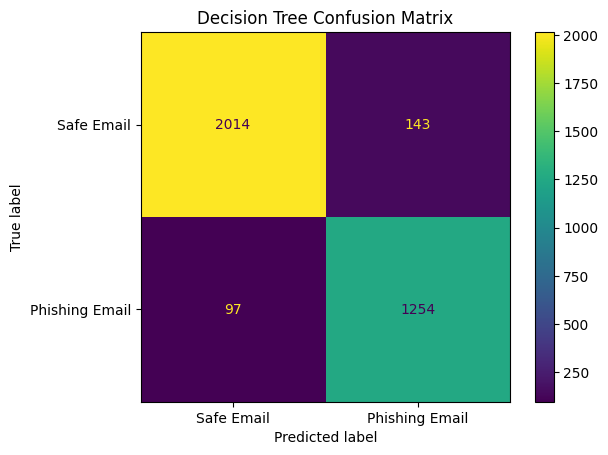

In [120]:
dtr = DecisionTreeClassifier() #passing object
dtr.fit(x_train_ml,y_train_ml)

#prediction
pred_dtr = dtr.predict(x_test_ml)

#performance
print(f"accuracy from Decision Tree:{accuracy_score(y_test_ml,pred_dtr)*100:.2f} %")
print(f"f1 score from Decision Tree: {f1_score(y_test_ml,pred_dtr)*100:.2f} %")
print("classification report : \n",classification_report(y_test_ml,pred_dtr))

#confusion matrix
clf_dtr = confusion_matrix(y_test_ml,pred_dtr)
cx_ = ConfusionMatrixDisplay(clf_dtr,display_labels=['Safe Email','Phishing Email']).plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

**6.Random Forest**

Random Forest:
    An ensemble of many decision trees.
    Each tree is trained on a random bootstrap sample of the data,
    and at each split, only a random subset of features is considered.
    
    → Reduces overfitting through averaging (bagging).
    → More robust than a single decision tree.
    Final prediction = majority vote across all trees.

accuracy from random forest:97.61 %
f1 score from random forest: 96.90 %
classification report : 
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      2157
           1       0.97      0.97      0.97      1351

    accuracy                           0.98      3508
   macro avg       0.97      0.98      0.97      3508
weighted avg       0.98      0.98      0.98      3508



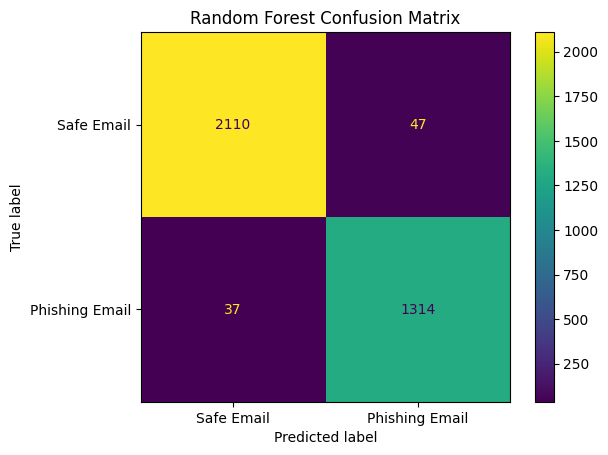

In [121]:
rnf = RandomForestClassifier() #passing object
rnf.fit(x_train_ml,y_train_ml)

#prediction
pred_rnf = rnf.predict(x_test_ml)

#performance
print(f"accuracy from random forest:{accuracy_score(y_test_ml,pred_rnf)*100:.2f} %")
print(f"f1 score from random forest: {f1_score(y_test_ml,pred_rnf)*100:.2f} %")
print("classification report : \n",classification_report(y_test_ml,pred_rnf))

#confusion matrix
clf_rnf = confusion_matrix(y_test_ml,pred_rnf)
cx_ = ConfusionMatrixDisplay(clf_rnf,display_labels=['Safe Email','Phishing Email']).plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

**7.MLP Classifier**

MLPClassifier (Multi-Layer Perceptron):
    A classic feed-forward neural network (sklearn implementation).
    Default: 1 hidden layer with 100 neurons, ReLU activation, Adam optimizer.
    - Input: TF-IDF vectors (10,000 features)
    - Hidden layers: Learn non-linear combinations of features
    - Output: Probability of phishing via sigmoid/softmax
    Trained via backpropagation. More powerful than linear models but
    slower and needs more tuning.

accuracy from MLP:98.40 %
f1 score from MLP: 97.92 %
classification report : 
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      2157
           1       0.98      0.98      0.98      1351

    accuracy                           0.98      3508
   macro avg       0.98      0.98      0.98      3508
weighted avg       0.98      0.98      0.98      3508



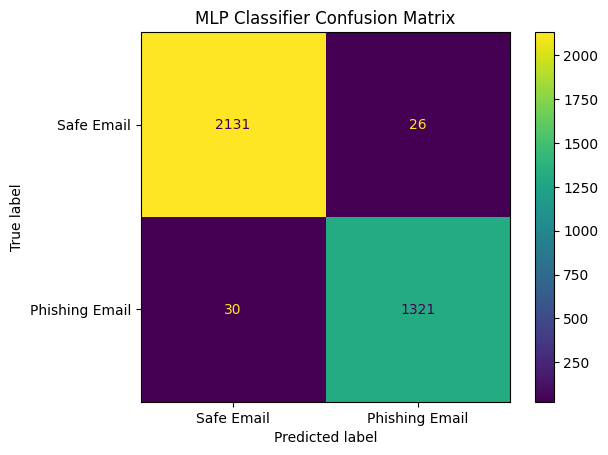

In [122]:
mlp = MLPClassifier()  # passing object
mlp.fit(x_train_ml,y_train_ml)

#prediction
pred_mlp = mlp.predict(x_test_ml)

#performance
print(f"accuracy from MLP:{accuracy_score(y_test_ml,pred_mlp)*100:.2f} %")
print(f"f1 score from MLP: {f1_score(y_test_ml,pred_mlp)*100:.2f} %")
print("classification report : \n",classification_report(y_test_ml,pred_mlp))

#confusion matrix
clf_mlp = confusion_matrix(y_test_ml,pred_mlp)
cx_ = ConfusionMatrixDisplay(clf_mlp,display_labels=['Safe Email','Phishing Email']).plot()
plt.title("MLP Classifier Confusion Matrix")
plt.show()

    **EDA comparison of the models performances**
Summary bar chart comparing all classical ML models.
Interms of F1_Score and Accuracy


In [123]:
models = ['Naive bayes', 'Logistic Regression', 'SGD Classifier', 'XGBoost', 'Decision Tree', 'Random Forest', 'MLPClassifier']
accuracies = [97.52, 97.95, 98.57, 97.21, 93.67, 97.72, 98.29]

# Create the bar chart
fig = px.bar(x=models, y=accuracies, labels={'x': 'Models', 'y': 'Accuracy'},
             title="Performance of the models", text=accuracies)

# Customize the layout (optional)
fig.update_traces(texttemplate='%{text:.2f}%', textposition='outside', marker_color='green')

# Show the plot
fig.show()

In [124]:
models = ['Naive bayes', 'Logistic Regression', 'SGD Classifier', 'XGBoost', 'Decision Tree', 'Random Forest', 'MLPClassifier']
f1_scores = [96.80, 97.31, 98.00, 96.45, 91.13, 97.03, 97.92]

# Create the bar chart
fig = px.bar(x=models, y=f1_scores, labels={'x': 'Models', 'y': 'F1 Score'}, # Changed y-axis label
             title="F1 Score Performance of the Models", text=f1_scores) # Changed title

# Customize the layout (optional)
fig.update_traces(texttemplate='%{text:.2f}%', textposition='outside', marker_color='purple') # Changed marker color

# Show the plot
fig.show()




NEURAL NETWORK(NN) PREPROCESSING (Tokenisation + Padding)

Deep learning models don't use TF-IDF. Instead they work with:

    1. Tokenisation: map each word to a unique integer ID
    2. Sequences: convert each email to a list of integer IDs
    3. Padding: make all sequences the same length (for batch processing)
    4. Embedding: the model itself learns dense word vectors during training

In [209]:
max_len = 150 # Maximum sequence length. Emails longer than 150 tokens are truncated;
# shorter ones are zero-padded. 150 was chosen as a reasonable trade-off
# between capturing enough context and keeping computation manageable.

tk = Tokenizer()  # Creates a tokeniser that will build a vocabulary from the training data.

# Process the text

tk.fit_on_texts(df['Email Text'])
sequences = tk.texts_to_sequences(df['Email Text']) # Converts each email string into a list of integer IDs.
vector = pad_sequences(sequences,padding='post', maxlen=max_len)

In [160]:
len(vector)#The length of generated vector

17538

In [161]:
x = np.array(vector) # Features: padded integer sequences
y = np.array(df["Email Type"]) # Labels: 0/1

# New train/test  dataset split for deep learning models

In [166]:
x_train, x_test, y_train, y_test = train_test_split(vector,df['Email Type'], test_size=0.2, random_state =0)

**1.SimpleNN (Neural Network)**
Architecture:
    Embedding → SimpleRNN → Dropout → Dense(sigmoid)


In [211]:
model_smp = Sequential() # Sequential() API
model_smp.add(Embedding(input_dim=len(tk.word_index)+1,output_dim=50,input_length=150))
model_smp.add(SimpleRNN(units=100))
model_smp.add(Dropout(0.45))
model_smp .add(Dense(1, activation='sigmoid'))

In [212]:
model_smp.compile(loss='binary_crossentropy' , optimizer='adam', metrics=['accuracy'])

In [213]:
model_smp.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [214]:
historical_smp  = model_smp.fit(x_train,y_train, epochs=7, batch_size=16, validation_data=(x_test,y_test))

Epoch 1/7
877/877 ━━━━━━━━━━━━━━━━━━━━ 158s 177ms/step - accuracy: 0.5777 - loss: 0.6947 - val_accuracy: 0.6360 - val_loss: 0.6253
Epoch 2/7
877/877 ━━━━━━━━━━━━━━━━━━━━ 201s 176ms/step - accuracy: 0.6850 - loss: 0.5997 - val_accuracy: 0.7252 - val_loss: 0.5765
Epoch 3/7
877/877 ━━━━━━━━━━━━━━━━━━━━ 202s 176ms/step - accuracy: 0.7378 - loss: 0.5178 - val_accuracy: 0.6545 - val_loss: 0.6000
Epoch 4/7
877/877 ━━━━━━━━━━━━━━━━━━━━ 200s 174ms/step - accuracy: 0.7746 - loss: 0.4650 - val_accuracy: 0.8597 - val_loss: 0.3710
Epoch 5/7
877/877 ━━━━━━━━━━━━━━━━━━━━ 202s 174ms/step - accuracy: 0.8906 - loss: 0.3245 - val_accuracy: 0.8740 - val_loss: 0.3479
Epoch 6/7
877/877 ━━━━━━━━━━━━━━━━━━━━ 153s 174ms/step - accuracy: 0.7309 - loss: 0.5086 - val_accuracy: 0.7802 - val_loss: 0.5146
Epoch 7/7
877/877 ━━━━━━━━━━━━━━━━━━━━ 203s 175ms/step - accuracy: 0.7746 - loss: 0.4662 - val_accuracy: 0.7092 - val_loss: 0.5289


Text(0, 0.5, 'Loss')

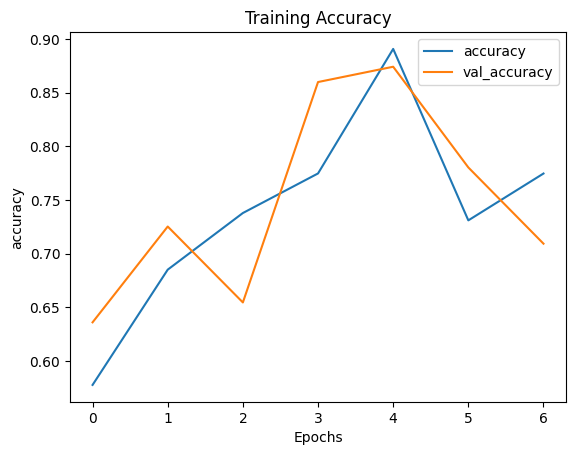

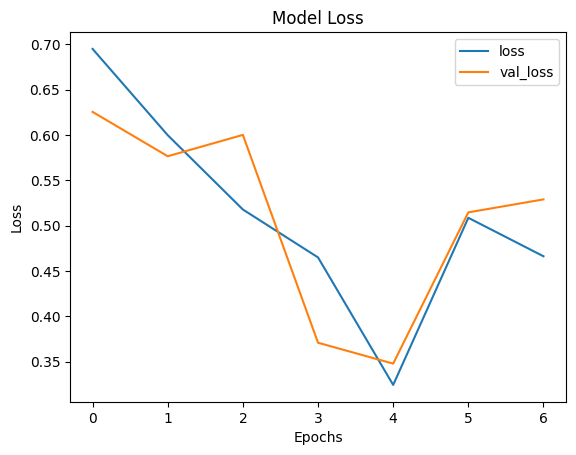

In [215]:
import matplotlib.pyplot as plt
pd.DataFrame(historical_smp.history)

pd.DataFrame(historical_smp.history)[['accuracy', 'val_accuracy']].plot()
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('accuracy')

pd.DataFrame(historical_smp.history)[['loss', 'val_loss']].plot()
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


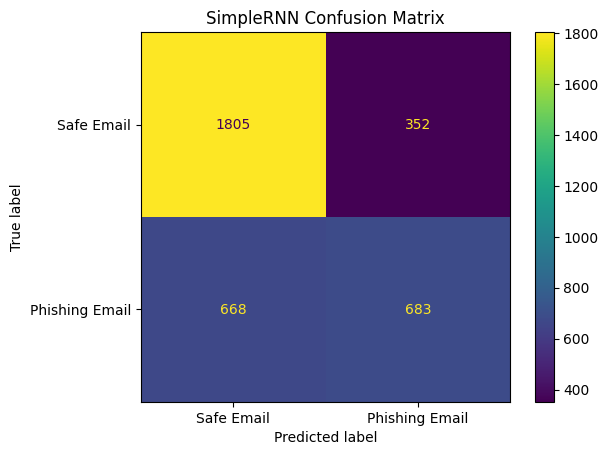

In [216]:
y_pred_prob_smp = model_smp.predict(x_test)
y_pred_smp = (y_pred_prob_smp > 0.5).astype(int)

from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cnf_smp = confusion_matrix(y_test,y_pred_smp)
ax_smp = ConfusionMatrixDisplay(confusion_matrix=cnf_smp,display_labels=['Safe Email','Phishing Email']).plot()
plt.title("SimpleRNN Confusion Matrix")
plt.show()

**2.LSTM Architecture**

In [169]:
model = Sequential() # Sequential() API
model.add(Embedding(input_dim=len(tk.word_index)+1,output_dim=50,input_length=150))
model.add(LSTM(units=100))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

In [170]:
model.compile(loss='binary_crossentropy' , optimizer='adam', metrics=['accuracy'])

In [171]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [172]:
historical  = model.fit(x_train,y_train, epochs=5, batch_size=16, validation_data=(x_test,y_test))

Epoch 1/5
877/877 ━━━━━━━━━━━━━━━━━━━━ 203s 226ms/step - accuracy: 0.7443 - loss: 0.4924 - val_accuracy: 0.9290 - val_loss: 0.2386
Epoch 2/5
877/877 ━━━━━━━━━━━━━━━━━━━━ 198s 222ms/step - accuracy: 0.9429 - loss: 0.1949 - val_accuracy: 0.9444 - val_loss: 0.1953
Epoch 3/5
877/877 ━━━━━━━━━━━━━━━━━━━━ 194s 222ms/step - accuracy: 0.9610 - loss: 0.1391 - val_accuracy: 0.9644 - val_loss: 0.1388
Epoch 4/5
877/877 ━━━━━━━━━━━━━━━━━━━━ 194s 221ms/step - accuracy: 0.9800 - loss: 0.0761 - val_accuracy: 0.9706 - val_loss: 0.1029
Epoch 5/5
877/877 ━━━━━━━━━━━━━━━━━━━━ 194s 221ms/step - accuracy: 0.9876 - loss: 0.0530 - val_accuracy: 0.9718 - val_loss: 0.1163


  Performance Analysis

In [173]:
results = model.evaluate(x_test, y_test)
loss = results[0]  # Extract the loss from the results
accuracy = results[1]  # Extract the accuracy from the results

print(f"Model Loss: {loss}")
print(f"Model Accuracy: {accuracy*100}")

110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.9718 - loss: 0.1163
Model Loss: 0.11628950387239456
Model Accuracy: 97.17788100242615


In [174]:
y_pred_prob = model.predict(x_test)
y_pred = (y_pred_prob > 0.5).astype(int)

110/110 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step


Text(0, 0.5, 'Loss')

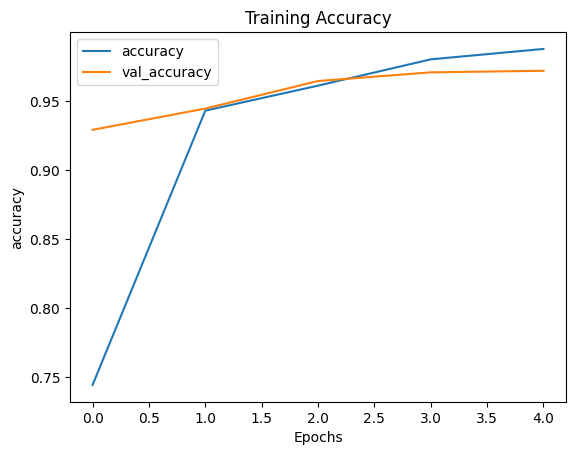

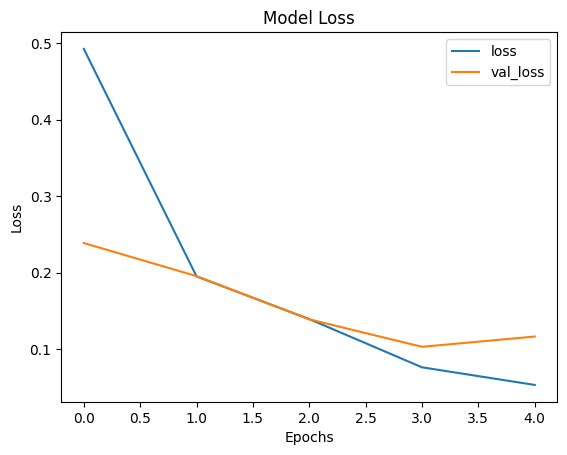

In [175]:
pd.DataFrame(historical.history)

pd.DataFrame(historical.history)[['accuracy', 'val_accuracy']].plot()
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('accuracy')

pd.DataFrame(historical.history)[['loss', 'val_loss']].plot()
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

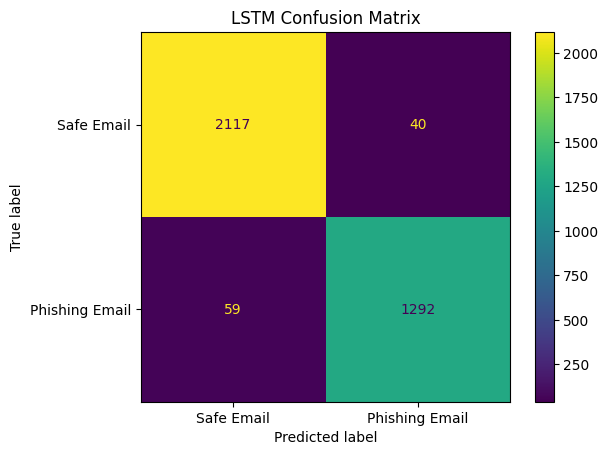

In [181]:
cnf = confusion_matrix(y_test,y_pred)
ax = ConfusionMatrixDisplay(confusion_matrix=cnf,display_labels=['Safe Email','Phishing Email'])
ax.plot()
plt.title("LSTM Confusion Matrix")
plt.show()

**3.Bidirectional**

In [182]:
model_bi = Sequential() # Sequential() API
model_bi.add(Embedding(input_dim=len(tk.word_index)+1,output_dim=50,input_length=150))
model_bi.add(Bidirectional(LSTM(units=100)))
model_bi.add(Dropout(0.5))
model_bi.add(Dense(1, activation='sigmoid'))

In [183]:
model_bi.compile(loss='binary_crossentropy' , optimizer='adam', metrics=['accuracy'])

In [184]:
model_bi.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [201]:
historical_bi  = model_bi.fit(x_train,y_train, epochs=2, batch_size=16, validation_data=(x_test,y_test))

Epoch 1/2
877/877 ━━━━━━━━━━━━━━━━━━━━ 268s 306ms/step - accuracy: 0.9949 - loss: 0.0167 - val_accuracy: 0.9746 - val_loss: 0.1113
Epoch 2/2
877/877 ━━━━━━━━━━━━━━━━━━━━ 323s 307ms/step - accuracy: 0.9949 - loss: 0.0163 - val_accuracy: 0.9763 - val_loss: 0.1053


In [202]:
model_bi.evaluate(x_test,y_test)

110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.9763 - loss: 0.1053


[0.10528721660375595, 0.9763398170471191]

In [203]:
y_pred_prob_bi = model_bi.predict(x_test)
y_pred_bi = (y_pred_prob_bi > 0.5).astype(int)

110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step


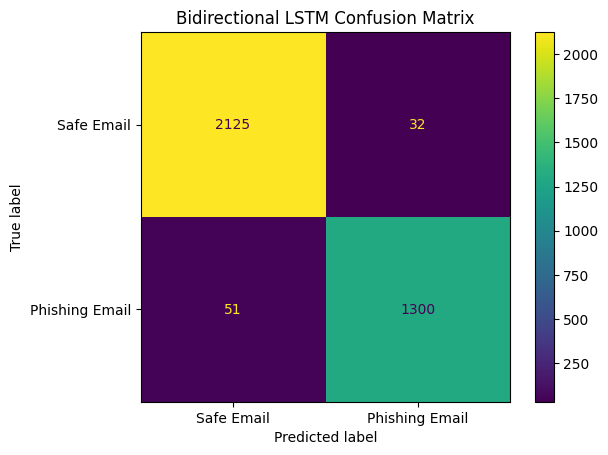

In [204]:
cnf_bi = confusion_matrix(y_test,y_pred_bi)
ax_bi = ConfusionMatrixDisplay(confusion_matrix=cnf_bi,display_labels=['Safe Email','Phishing Email'])
ax_bi.plot()
plt.title("Bidirectional LSTM Confusion Matrix")
plt.show()

4.GRU (Gated Recurrent Unit)

In [191]:
model_gru = Sequential() # Sequential() API
model_gru.add(Embedding(input_dim=len(tk.word_index)+1,output_dim=50,input_length=150))
model_gru.add(GRU(units=100))
model_gru.add(Dropout(0.5))
model_gru.add(Dense(1, activation='sigmoid'))

In [192]:
model_gru.compile(loss='binary_crossentropy' , optimizer='adam', metrics=['accuracy'])
model_gru.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [193]:
model_gru.fit(x_train,y_train, epochs=3, batch_size=16, validation_data=(x_test,y_test))

Epoch 1/3
877/877 ━━━━━━━━━━━━━━━━━━━━ 227s 250ms/step - accuracy: 0.7326 - loss: 0.4998 - val_accuracy: 0.9621 - val_loss: 0.1367
Epoch 2/3
877/877 ━━━━━━━━━━━━━━━━━━━━ 263s 252ms/step - accuracy: 0.9769 - loss: 0.0728 - val_accuracy: 0.9818 - val_loss: 0.0593
Epoch 3/3
877/877 ━━━━━━━━━━━━━━━━━━━━ 257s 246ms/step - accuracy: 0.9957 - loss: 0.0167 - val_accuracy: 0.9729 - val_loss: 0.1132


In [194]:
y_pred_prob_gru = model_gru.predict(x_test)
y_pred_gru = (y_pred_prob_gru > 0.5).astype(int)

110/110 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step


In [197]:
y_pred_prob_gru = model_gru.predict(x_test)
y_pred_gru = (y_pred_prob_gru > 0.5).astype(int)

110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step


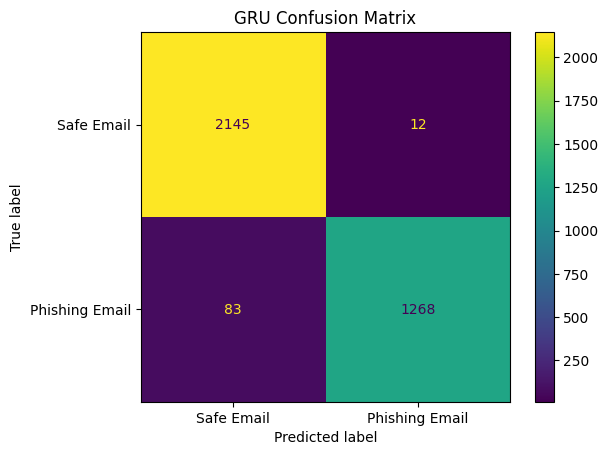

In [198]:
cnf_gru = confusion_matrix(y_test,y_pred_gru)
ax_gru = ConfusionMatrixDisplay(confusion_matrix=cnf_gru,display_labels=['Safe Email','Phishing Email'])
ax_gru.plot()
plt.title("GRU Confusion Matrix")
plt.show()

## Deep Learning Models Performance Comparison

In [205]:
dl_models = ['SimpleRNN', 'LSTM', 'Bidirectional LSTM', 'GRU']
dl_accuracies = [
    historical_smp.history['val_accuracy'][-1] * 100, # Final validation accuracy for SimpleRNN
    historical.history['val_accuracy'][-1] * 100,     # Final validation accuracy for LSTM
    historical_bi.history['val_accuracy'][-1] * 100,  # Final validation accuracy for Bidirectional LSTM
    model_gru.history.history['val_accuracy'][-1] * 100 # Final validation accuracy for GRU
]

# Create the bar chart
fig_dl = px.bar(x=dl_models, y=dl_accuracies, labels={'x': 'Deep Learning Models', 'y': 'Accuracy (%)'},
             title="Performance of Deep Learning Models", text=dl_accuracies)

# Customize the layout
fig_dl.update_traces(texttemplate='%{text:.2f}%', textposition='outside', marker_color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])

# Show the plot
fig_dl.show()